# Trump Tweet Event Study: Industry Return Analysis
## Using EVENT STUDY PANELS BY SINGLE INDUSTRY

**Research Design:**
- **Event Window:** [-5, +5] trading days around each tweet
- **Estimation Window:** [-250, -10] trading days before each tweet
- **Market Model:** CAPM single-factor model
- **Expected Return:** $\hat{R}_{i,t} = \hat{\alpha}_i + \hat{\beta}_i \cdot R_{m,t}$
- **Abnormal Return:** $AR_{i,t} = R_{i,t} - \hat{R}_{i,t}$
- **AAR:** $AAR_t = \frac{1}{N}\sum_{i=1}^{N} AR_{i,t}$
- **CAAR:** $CAAR_{[t_1,t_2]} = \sum_{t=t_1}^{t_2} AAR_t$

**Data source:** `EVENT STUDY PANELS BY SINGLE INDUSTRY`  
Each file = one tweet × one industry (e.g. `News_panel_tweet_id_XXXX.csv`)

---
## Step 0: Import Libraries & Configuration

In [ ]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# ── Paths — UPDATE THESE TO YOUR LOCAL PATHS ───────────────────────────────
SP500_PATH        = "sp500_2013_2022_daily.csv"
SINGLE_IND_DIR    = "EVENT STUDY PANELS BY SINGLE INDUSTRY"

# ── Window parameters ──────────────────────────────────────────────────────
EST_START = -250
EST_END   = -10
EVT_START = -5
EVT_END   =  5
event_days = list(range(EVT_START, EVT_END + 1))

# ── Industry file prefix → return column name mapping ─────────────────────
# Key   = prefix used in filename  (e.g. "News" in News_panel_tweet_id_XXX.csv)
# Value = (return column name in CSV, display label)
INDUSTRY_MAP = {
    'Airl':   ('Airlines_&_Travel_daily_return',                          'Airlines & Travel'),
    'Auto':   ('Automobiles_&_Auto_Components_daily_return',              'Automobiles'),
    'Chem':   ('Chemicals_(Materials_sector)_daily_return',               'Chemicals'),
    'Cons':   ('Construction_&_Infrastructure_daily_return',              'Construction'),
    'Defe':   ('Defense_&_Aerospace_daily_return',                        'Defense & Aerospace'),
    'Fina':   ('Financials_(Banks)_daily_return',                         'Financials (Banks)'),
    'News':   ('News_&_Publishing_daily_return',                          'News & Publishing'),
    'Oil':    ('Oil_&_Natural_Gas_daily_return',                          'Oil & Gas'),
    'Semi':   ('Semiconductors_(Information_Technology_sector)_daily_return', 'Semiconductors'),
    'Tech':   ('Technology_&_Internet_daily_return',                      'Technology & Internet'),
}

INDUSTRIES     = list(INDUSTRY_MAP.keys())           # prefixes
INDUSTRY_COLS  = {k: v[0] for k, v in INDUSTRY_MAP.items()}   # col names
INDUSTRY_LABELS= {k: v[1] for k, v in INDUSTRY_MAP.items()}   # display labels

colors = plt.cm.tab10(np.linspace(0, 1, 10))
COLOR_MAP = {ind: colors[i] for i, ind in enumerate(INDUSTRIES)}

def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return ''

print("✅ Configuration loaded.")
print(f"   Industries tracked: {len(INDUSTRIES)}")
print(f"   Estimation window: [{EST_START}, {EST_END}]")
print(f"   Event window:      [{EVT_START}, {EVT_END}]")

✅ Configuration loaded.
   Industries tracked: 10
   Estimation window: [-250, -10]
   Event window:      [-5, 5]


---
## Step 1: Load Data

**Goal:** For each industry prefix, load all matching `{prefix}_panel_tweet_id_*.csv` files.
Each file contains one tweet's time-series for that industry.

In [20]:
# ── Load S&P 500 market returns ────────────────────────────────────────────
sp500 = pd.read_csv(SP500_PATH, skiprows=[1], parse_dates=['Date'])
sp500 = sp500[['Date', 'Market_Return']].dropna()
sp500['Market_Return'] = pd.to_numeric(sp500['Market_Return'], errors='coerce')
sp500 = sp500.dropna().set_index('Date').sort_index()

print(f"✅ S&P 500 loaded: {len(sp500)} trading days "
      f"({sp500.index.min().date()} → {sp500.index.max().date()})")

✅ S&P 500 loaded: 2517 trading days (2013-01-03 → 2022-12-30)


In [21]:
# ── Load all single-industry panel files, grouped by industry ──────────────
# Structure: panels[prefix] = list of DataFrames (one per tweet)
panels = {}   # prefix → list of (tweet_id, DataFrame)

for prefix in INDUSTRIES:
    pattern = os.path.join(SINGLE_IND_DIR, f"{prefix}_panel_tweet_id_*.csv")
    files   = sorted(glob.glob(pattern))
    
    tweet_panels = []
    for f in files:
        tid = os.path.basename(f).replace(f"{prefix}_panel_tweet_id_", "").replace(".csv", "")
        df  = pd.read_csv(f, parse_dates=['Day'])
        df['t'] = pd.to_numeric(df['t'], errors='coerce')
        df  = df.dropna(subset=['t']).set_index('t').sort_index()
        
        # Merge S&P 500 market returns by calendar date
        df2 = df.reset_index()
        df2['Day'] = pd.to_datetime(df2['Day'])
        df2 = df2.merge(
            sp500.reset_index().rename(columns={'Date': 'Day'}),
            on='Day', how='left'
        ).set_index('t').sort_index()
        
        tweet_panels.append((tid, df2))
    
    panels[prefix] = tweet_panels
    print(f"   {INDUSTRY_LABELS[prefix]:<35} {len(tweet_panels):>4} tweet files loaded")

total_files = sum(len(v) for v in panels.values())
print(f"\n✅ Total files loaded: {total_files}")

# Preview one file
sample_prefix = 'News'
sample_tid, sample_df = panels[sample_prefix][0]
print(f"\nSample — {INDUSTRY_LABELS[sample_prefix]} tweet_id={sample_tid}:")
print(sample_df.head(4))

   Airlines & Travel                      6 tweet files loaded
   Automobiles                           14 tweet files loaded
   Chemicals                              1 tweet files loaded
   Construction                           1 tweet files loaded
   Defense & Aerospace                   10 tweet files loaded
   Financials (Banks)                     6 tweet files loaded
   News & Publishing                     91 tweet files loaded
   Oil & Gas                              1 tweet files loaded
   Semiconductors                        16 tweet files loaded
   Technology & Internet                 87 tweet files loaded

✅ Total files loaded: 233

Sample — News & Publishing tweet_id=1000391997969092608:
            Day  News_&_Publishing_daily_return  Market_Return
t                                                             
-250 2017-06-26                        0.011519       0.000316
-249 2017-06-27                       -0.005080      -0.008073
-248 2017-06-28                  

---
## Step 2: Estimate Alpha & Beta via OLS (Estimation Window)

**Goal:** For each tweet × industry, run OLS over t ∈ [-250, -10]:

$$R_{i,t} = \alpha_i + \beta_i \cdot R_{m,t} + \epsilon_{i,t}$$

In [22]:
def estimate_capm(df, ret_col, est_start=EST_START, est_end=EST_END, min_obs=30):
    """
    OLS regression over the estimation window.
    Returns (alpha, beta, r2, n_obs) or (NaN, NaN, NaN, 0).
    """
    est = df[(df.index >= est_start) & (df.index <= est_end)][['Market_Return', ret_col]].dropna()
    if len(est) < min_obs:
        return np.nan, np.nan, np.nan, 0
    X = sm.add_constant(est['Market_Return'].values)
    try:
        m = sm.OLS(est[ret_col].values, X).fit()
        return m.params[0], m.params[1], m.rsquared, len(est)
    except:
        return np.nan, np.nan, np.nan, 0


# ── Run CAPM estimation for every tweet × industry ────────────────────────
# param_store[prefix] = dict: tweet_id → (alpha, beta, r2, n)
param_store = {}
param_records = []  # flat list for diagnostics

for prefix in INDUSTRIES:
    ret_col = INDUSTRY_COLS[prefix]
    param_store[prefix] = {}
    
    for tid, df in panels[prefix]:
        if ret_col not in df.columns:
            # Try to find the return column automatically
            ret_cols = [c for c in df.columns if 'return' in c.lower()]
            ret_col_actual = ret_cols[0] if ret_cols else None
        else:
            ret_col_actual = ret_col
        
        if ret_col_actual is None:
            param_store[prefix][tid] = (np.nan, np.nan, np.nan, 0)
            continue
        
        alpha, beta, r2, n = estimate_capm(df, ret_col_actual)
        param_store[prefix][tid] = (alpha, beta, r2, n)
        param_records.append({
            'prefix': prefix, 'industry': INDUSTRY_LABELS[prefix],
            'tweet_id': tid, 'alpha': alpha, 'beta': beta, 'r2': r2, 'n': n
        })

params_df = pd.DataFrame(param_records)
valid     = params_df.dropna(subset=['alpha'])
print(f"✅ CAPM estimated: {len(valid)} valid pairs, {params_df['alpha'].isna().sum()} dropped.")
print("\nMedian parameters by industry:")
print(valid.groupby('industry')[['alpha','beta','r2','n']]
      .median().round(4).to_string())

✅ CAPM estimated: 233 valid pairs, 0 dropped.

Median parameters by industry:
                        alpha    beta      r2      n
industry                                            
Airlines & Travel     -0.0004  1.1622  0.5385  222.0
Automobiles           -0.0003  1.0569  0.4376  222.0
Chemicals             -0.0001  1.0484  0.3625  228.0
Construction           0.0004  1.0853  0.4705  221.0
Defense & Aerospace    0.0003  0.8881  0.4427  225.0
Financials (Banks)    -0.0000  1.1920  0.7190  228.5
News & Publishing      0.0006  0.7580  0.2641  223.0
Oil & Gas             -0.0003  1.0758  0.3715  226.0
Semiconductors         0.0005  1.5456  0.3590  223.0
Technology & Internet  0.0004  1.2706  0.6096  223.0


### Step 2a: Validate Estimation Quality

**Goal:** Confirm R² and β distributions are reasonable before computing abnormal returns.

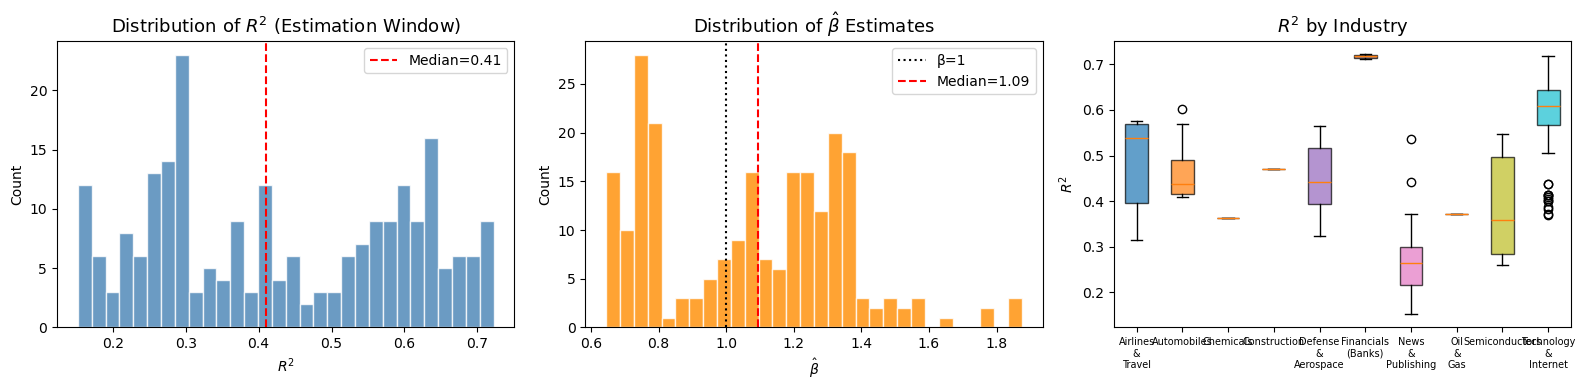

✅ Saved: estimation_quality.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# R² distribution
axes[0].hist(valid['r2'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(valid['r2'].median(), color='red', linestyle='--',
                label=f"Median={valid['r2'].median():.2f}")
axes[0].set_title('Distribution of $R^2$ (Estimation Window)', fontsize=13)
axes[0].set_xlabel('$R^2$'); axes[0].set_ylabel('Count'); axes[0].legend()

# Beta distribution
axes[1].hist(valid['beta'], bins=30, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(1.0, color='black', linestyle=':', label='β=1')
axes[1].axvline(valid['beta'].median(), color='red', linestyle='--',
                label=f"Median={valid['beta'].median():.2f}")
axes[1].set_title('Distribution of $\\hat{\\beta}$ Estimates', fontsize=13)
axes[1].set_xlabel('$\\hat{\\beta}$'); axes[1].set_ylabel('Count'); axes[1].legend()

# R² by industry (boxplot)
r2_by_ind = [valid[valid['prefix'] == p]['r2'].values for p in INDUSTRIES]
short_labs = [INDUSTRY_LABELS[p].replace(' ', '\n') for p in INDUSTRIES]
bp = axes[2].boxplot(r2_by_ind, labels=short_labs, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_title('$R^2$ by Industry', fontsize=13)
axes[2].set_ylabel('$R^2$')
axes[2].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig('estimation_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: estimation_quality.png")

---
## Step 3: Compute Abnormal Returns in the Event Window

**Goal:** For each tweet × industry, compute AR over t ∈ [-5, +5]:

$$AR_{i,t} = R_{i,t} - (\hat{\alpha}_i + \hat{\beta}_i \cdot R_{m,t})$$

In [24]:
# ar_matrix[prefix][t] = list of AR values across all events
ar_matrix = {p: {t: [] for t in event_days} for p in INDUSTRIES}
total_ar, skipped = 0, 0

for prefix in INDUSTRIES:
    ret_col = INDUSTRY_COLS[prefix]
    
    for tid, df in panels[prefix]:
        # Get actual return column (handle possible naming variants)
        if ret_col in df.columns:
            ret_col_actual = ret_col
        else:
            ret_cols = [c for c in df.columns if 'return' in c.lower()]
            ret_col_actual = ret_cols[0] if ret_cols else None
        
        if ret_col_actual is None:
            skipped += 1; continue
        
        alpha, beta, _, _ = param_store[prefix].get(tid, (np.nan, np.nan, np.nan, 0))
        if np.isnan(alpha) or np.isnan(beta):
            skipped += 1; continue
        
        evt = df[(df.index >= EVT_START) & (df.index <= EVT_END)]
        for t in event_days:
            if t not in evt.index: continue
            row = evt.loc[t]
            r_a = row[ret_col_actual]
            r_m = row['Market_Return']
            if pd.isna(r_a) or pd.isna(r_m): continue
            ar_matrix[prefix][t].append(r_a - (alpha + beta * r_m))
            total_ar += 1

print(f"✅ AR computed: {total_ar:,} observations | Skipped: {skipped}")
print("\nEvent count per industry at t=0:")
for p in INDUSTRIES:
    print(f"   {INDUSTRY_LABELS[p]:<35} N={len(ar_matrix[p][0])}")

✅ AR computed: 2,437 observations | Skipped: 0

Event count per industry at t=0:
   Airlines & Travel                   N=6
   Automobiles                         N=14
   Chemicals                           N=1
   Construction                        N=1
   Defense & Aerospace                 N=10
   Financials (Banks)                  N=3
   News & Publishing                   N=88
   Oil & Gas                           N=1
   Semiconductors                      N=16
   Technology & Internet               N=85


---
## Step 4: Compute AAR and CAAR

$$AAR_t = \frac{1}{N_t}\sum AR_{i,t} \qquad CAAR_{[-5,t]} = \sum_{\tau=-5}^{t} AAR_\tau$$

In [25]:
results = {}

for prefix in INDUSTRIES:
    rows = []
    for t in event_days:
        ars = ar_matrix[prefix][t]; n = len(ars)
        if n == 0:
            rows.append({'t':t,'AAR':np.nan,'SE':np.nan,'N':0,'t_stat':np.nan,'p_value':np.nan})
            continue
        aar = np.mean(ars)
        se  = np.std(ars, ddof=1) / np.sqrt(n)
        t_s = aar / se if se > 0 else np.nan
        p_v = 2 * stats.t.sf(abs(t_s), df=n-1) if not np.isnan(t_s) else np.nan
        rows.append({'t':t,'AAR':aar,'SE':se,'N':n,'t_stat':t_s,'p_value':p_v})
    
    df_r = pd.DataFrame(rows).set_index('t')
    df_r['CAAR']    = df_r['AAR'].cumsum()
    df_r['CAAR_SE'] = np.sqrt(df_r['SE'].pow(2).cumsum().replace(0, np.nan))
    df_r['CAAR_t']  = df_r['CAAR'] / df_r['CAAR_SE']
    df_r['CAAR_p']  = df_r.apply(
        lambda r: 2*stats.t.sf(abs(r['CAAR_t']), df=r['N']-1)
        if not np.isnan(r['CAAR_t']) else np.nan, axis=1)
    results[prefix] = df_r

print("✅ AAR and CAAR computed for all industries.")
print("\nSample — News & Publishing:")
print(results['News'][['AAR','CAAR','t_stat','p_value','N']].round(6))

✅ AAR and CAAR computed for all industries.

Sample — News & Publishing:
         AAR      CAAR    t_stat   p_value   N
t                                             
-5 -0.001410 -0.001410 -1.293472  0.199272  88
-4 -0.002243 -0.003652 -2.021009  0.046284  90
-3  0.001116 -0.002536  1.103370  0.272874  89
-2 -0.000674 -0.003210 -0.548998  0.584429  87
-1 -0.004734 -0.007944 -3.865162  0.000223  82
 0 -0.000531 -0.008475 -0.400186  0.690001  88
 1 -0.000677 -0.009152 -0.489549  0.625658  90
 2 -0.002370 -0.011521 -1.936901  0.055966  89
 3  0.000377 -0.011144  0.245832  0.806385  89
 4 -0.000630 -0.011774 -0.539229  0.591122  87
 5 -0.000014 -0.011788 -0.008031  0.993612  84


---
## Step 5: Significance Testing

**H₀:** $AAR_t = 0$ | Significance: * p<0.10, ** p<0.05, *** p<0.01

In [26]:
# ── Summary table: AAR(t=0) and CAAR[-5,+5] ───────────────────────────────
summary_rows = []
for prefix in INDUSTRIES:
    df_r = results[prefix]
    aar0  = df_r.loc[0, 'AAR']     if 0 in df_r.index else np.nan
    p0    = df_r.loc[0, 'p_value'] if 0 in df_r.index else np.nan
    caar5 = df_r.loc[EVT_END, 'CAAR']   if EVT_END in df_r.index else np.nan
    p5    = df_r.loc[EVT_END, 'CAAR_p'] if EVT_END in df_r.index else np.nan
    n     = df_r.loc[0, 'N']       if 0 in df_r.index else 0
    summary_rows.append({
        'Industry':        INDUSTRY_LABELS[prefix],
        'N Events':        int(n),
        'AAR(t=0)':        f"{aar0*100:.4f}%" if not pd.isna(aar0) else '-',
        'Sig(t=0)':        sig_stars(p0),
        'p(t=0)':          f"{p0:.4f}"        if not pd.isna(p0)   else '-',
        'CAAR[-5,+5]':     f"{caar5*100:.4f}%" if not pd.isna(caar5) else '-',
        'Sig CAAR':        sig_stars(p5),
        'p CAAR':          f"{p5:.4f}"         if not pd.isna(p5)   else '-',
    })

sig_table = pd.DataFrame(summary_rows)
print("=" * 95)
print("SIGNIFICANCE SUMMARY")
print("=" * 95)
print(sig_table.to_string(index=False))
print("\n* p<0.10  ** p<0.05  *** p<0.01")

SIGNIFICANCE SUMMARY
             Industry  N Events AAR(t=0) Sig(t=0) p(t=0) CAAR[-5,+5] Sig CAAR p CAAR
    Airlines & Travel         6  0.2433%          0.4856     0.8864%          0.4939
          Automobiles        14 -0.3586%          0.1176    -0.1596%          0.8606
            Chemicals         1  0.2249%               -           -               -
         Construction         1 -0.4025%               -    -1.9200%               -
  Defense & Aerospace        10 -0.2273%          0.2192    -0.9401%          0.3673
   Financials (Banks)         3  0.3914%          0.7495    -3.1047%          0.2794
    News & Publishing        88 -0.0531%          0.6900    -1.1788%      *** 0.0076
            Oil & Gas         1  0.4451%               -           -               -
       Semiconductors        16 -0.0474%          0.8870    -1.6419%          0.1625
Technology & Internet        85 -0.0203%          0.8445    -0.4282%          0.1991

* p<0.10  ** p<0.05  *** p<0.01


In [27]:
# ── Full day-by-day significance table ────────────────────────────────────
print("\nDay-by-day AAR (%) with significance:")
print("-" * 120)
header = f"{'t':>4}  " + "  ".join([f"{INDUSTRY_LABELS[p][:11]:>13}" for p in INDUSTRIES])
print(header); print("-" * 120)

for t in event_days:
    row_str = f"{t:>4}  "
    for p in INDUSTRIES:
        aar = results[p].loc[t, 'AAR']     if t in results[p].index else np.nan
        pv  = results[p].loc[t, 'p_value'] if t in results[p].index else np.nan
        cell = f"{aar*100:+.3f}%{sig_stars(pv)}" if not np.isnan(aar) else "    NaN  "
        row_str += f"{cell:>15}  "
    marker = " ◄ EVENT" if t == 0 else ""
    print(row_str + marker)
print("-" * 120)
print("* p<0.10  ** p<0.05  *** p<0.01")


Day-by-day AAR (%) with significance:
------------------------------------------------------------------------------------------------------------------------
   t    Airlines &     Automobiles      Chemicals    Constructio    Defense & A    Financials     News & Publ      Oil & Gas    Semiconduct    Technology 
------------------------------------------------------------------------------------------------------------------------
  -5          +0.113%          +0.424%          -0.155%          -1.818%          +0.001%          -0.274%          -0.141%          +0.603%          -0.136%          -0.023%  
  -4          -0.289%          -0.206%          -0.007%          -0.634%          +0.024%          -0.672%        -0.224%**          +0.241%          -0.342%          +0.034%  
  -3          -0.589%          +0.171%          -0.399%          +1.416%          -0.068%          -0.770%          +0.112%          -0.101%          -0.097%        -0.213%**  
  -2          +0.287%          -0

---
## Step 6: Visualizations

### 6a: AAR Heatmap

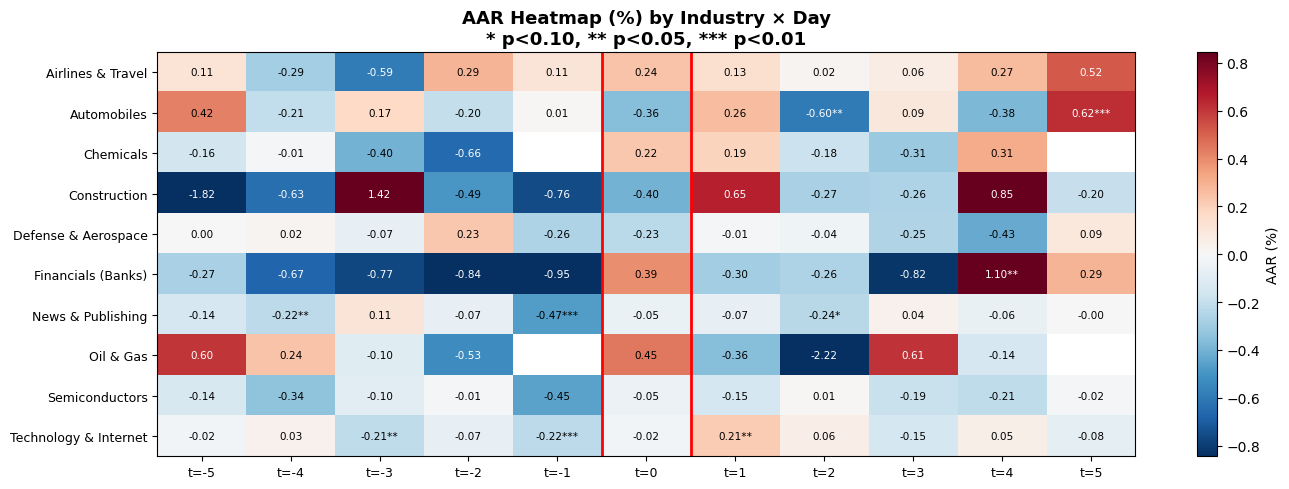

✅ Saved: AAR_heatmap.png


In [28]:
aar_mat  = np.full((len(INDUSTRIES), len(event_days)), np.nan)
pval_mat = np.full((len(INDUSTRIES), len(event_days)), np.nan)

for i, p in enumerate(INDUSTRIES):
    for j, t in enumerate(event_days):
        if t in results[p].index:
            aar_mat[i,j]  = results[p].loc[t,'AAR'] * 100
            pval_mat[i,j] = results[p].loc[t,'p_value']

fig, ax = plt.subplots(figsize=(14, 5))
vmax = np.nanpercentile(np.abs(aar_mat), 95)
im   = ax.imshow(aar_mat, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(INDUSTRIES)):
    for j in range(len(event_days)):
        val = aar_mat[i,j]
        if not np.isnan(val):
            stars = sig_stars(pval_mat[i,j])
            ax.text(j, i, f"{val:.2f}{stars}", ha='center', va='center',
                    fontsize=7.5,
                    color='black' if abs(val) < vmax*0.6 else 'white')

ax.set_xticks(range(len(event_days)))
ax.set_xticklabels([f't={t}' for t in event_days], fontsize=9)
ax.set_yticks(range(len(INDUSTRIES)))
ax.set_yticklabels([INDUSTRY_LABELS[p] for p in INDUSTRIES], fontsize=9)
ax.set_title('AAR Heatmap (%) by Industry × Day\n* p<0.10, ** p<0.05, *** p<0.01',
             fontsize=13, fontweight='bold')
ev_col = event_days.index(0)
ax.axvline(ev_col - 0.5, color='red', linewidth=2)
ax.axvline(ev_col + 0.5, color='red', linewidth=2)
plt.colorbar(im, ax=ax, label='AAR (%)')
plt.tight_layout()
plt.savefig('AAR_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: AAR_heatmap.png")

### 6b: CAAR by Industry (2×5 grid)

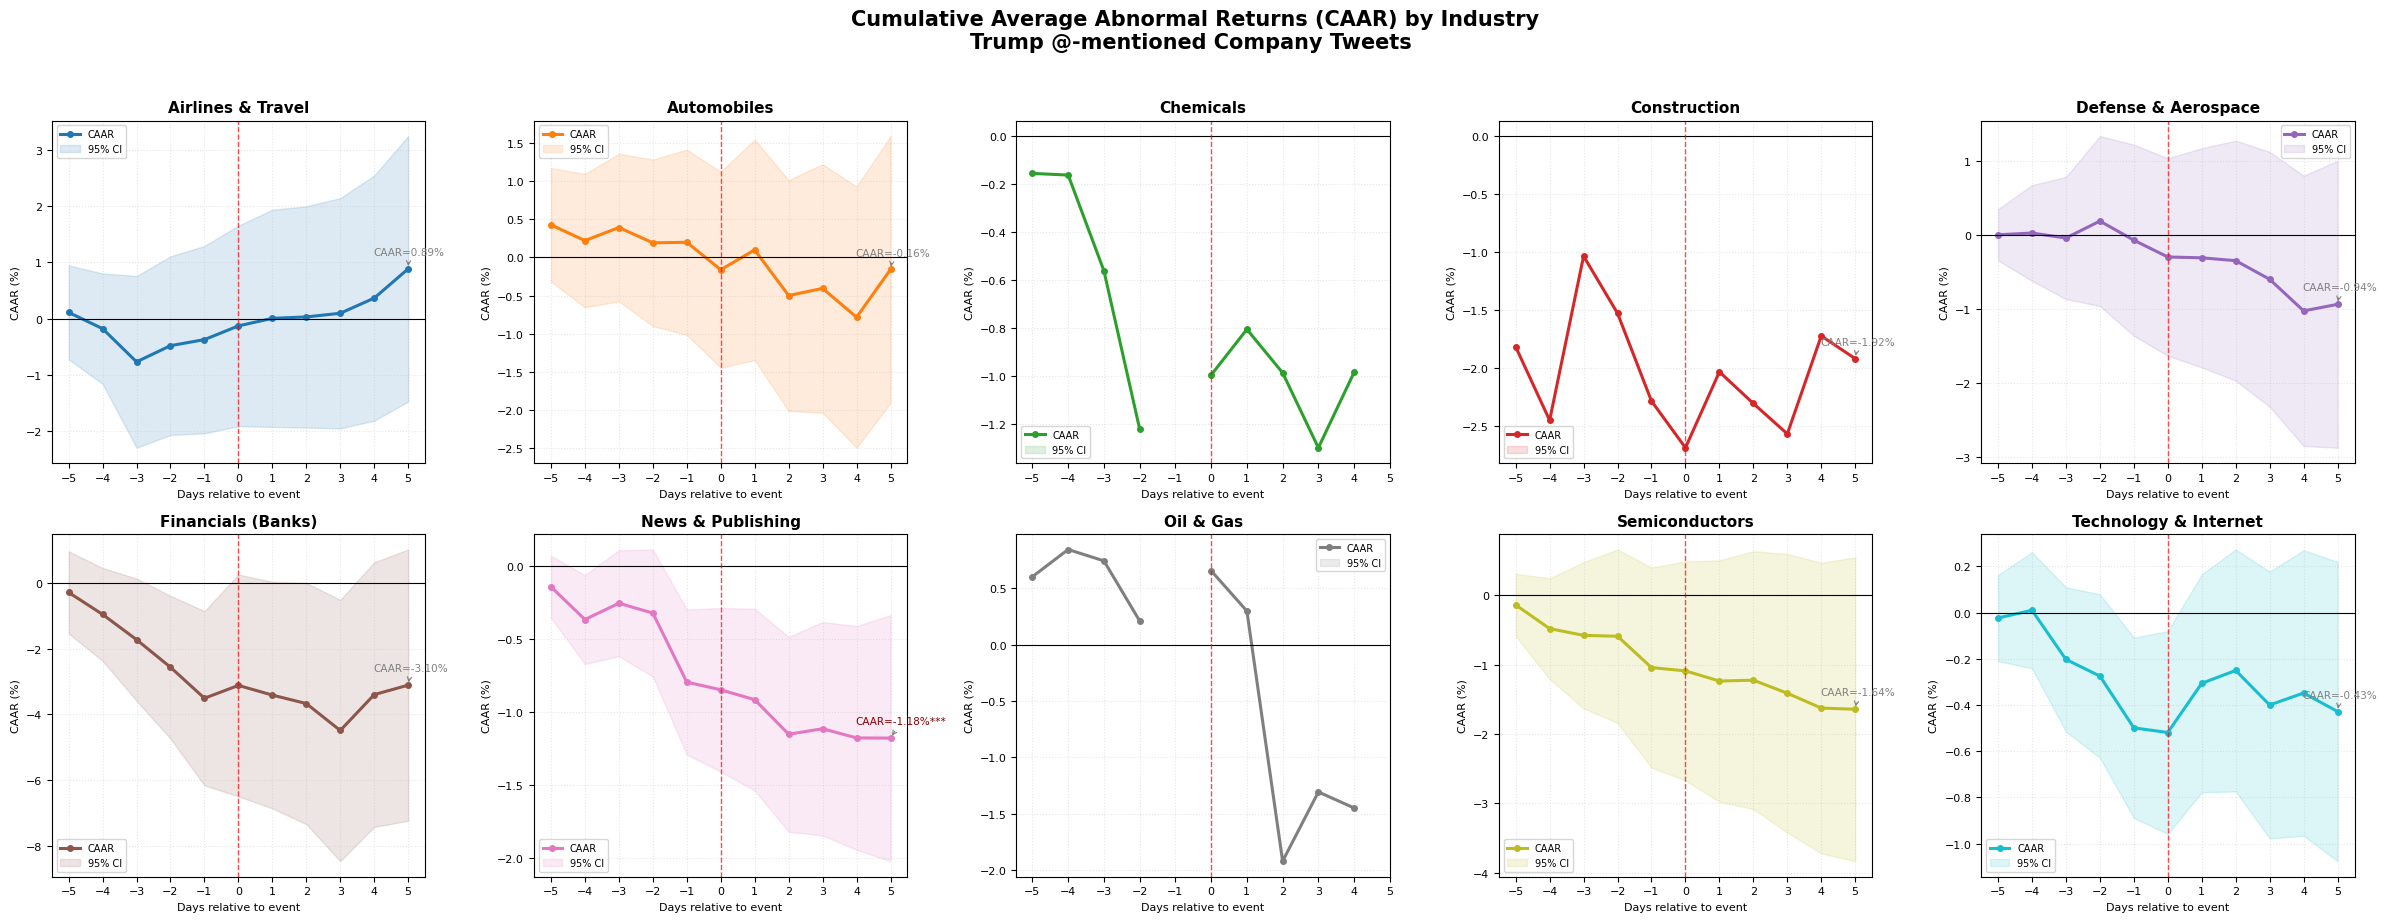

✅ Saved: CAAR_all_industries.png


In [37]:
fig, axes = plt.subplots(2, 5, figsize=(24, 9))
axes = axes.flatten()

for idx, prefix in enumerate(INDUSTRIES):
    ax   = axes[idx]
    df_r = results[prefix]
    t_v  = df_r.index.tolist()
    caar = df_r['CAAR'].values * 100
    cse  = df_r['CAAR_SE'].values * 100
    color = COLOR_MAP[prefix]

    ax.plot(t_v, caar, color=color, linewidth=2.2, marker='o', markersize=4, label='CAAR')
    ax.fill_between(t_v, caar - 1.96*cse, caar + 1.96*cse,
                    color=color, alpha=0.15, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='red',   linewidth=1, linestyle='--', alpha=0.7)

    # Annotate endpoint
    c5 = df_r.loc[EVT_END, 'CAAR'] * 100 if EVT_END in df_r.index else np.nan
    p5 = df_r.loc[EVT_END, 'CAAR_p']     if EVT_END in df_r.index else np.nan
    if not np.isnan(c5):
        label_txt = f'CAAR={c5:.2f}%{sig_stars(p5)}'
        ax.annotate(label_txt, xy=(EVT_END, c5),
                    xytext=(-25, 10), textcoords='offset points',
                    fontsize=7.5,
                    color='darkred' if sig_stars(p5) else 'gray',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

    ax.set_title(INDUSTRY_LABELS[prefix], fontsize=11, fontweight='bold')
    ax.set_xlabel('Days relative to event', fontsize=8)
    ax.set_ylabel('CAAR (%)', fontsize=8)
    ax.set_xticks(event_days)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3, linestyle=':')
    ax.legend(fontsize=7)

fig.suptitle('Cumulative Average Abnormal Returns (CAAR) by Industry\n'
             'Trump @-mentioned Company Tweets ',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('CAAR_all_industries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: CAAR_all_industries.png")

### 6c: AAR by Industry (2×5 grid with significance markers)

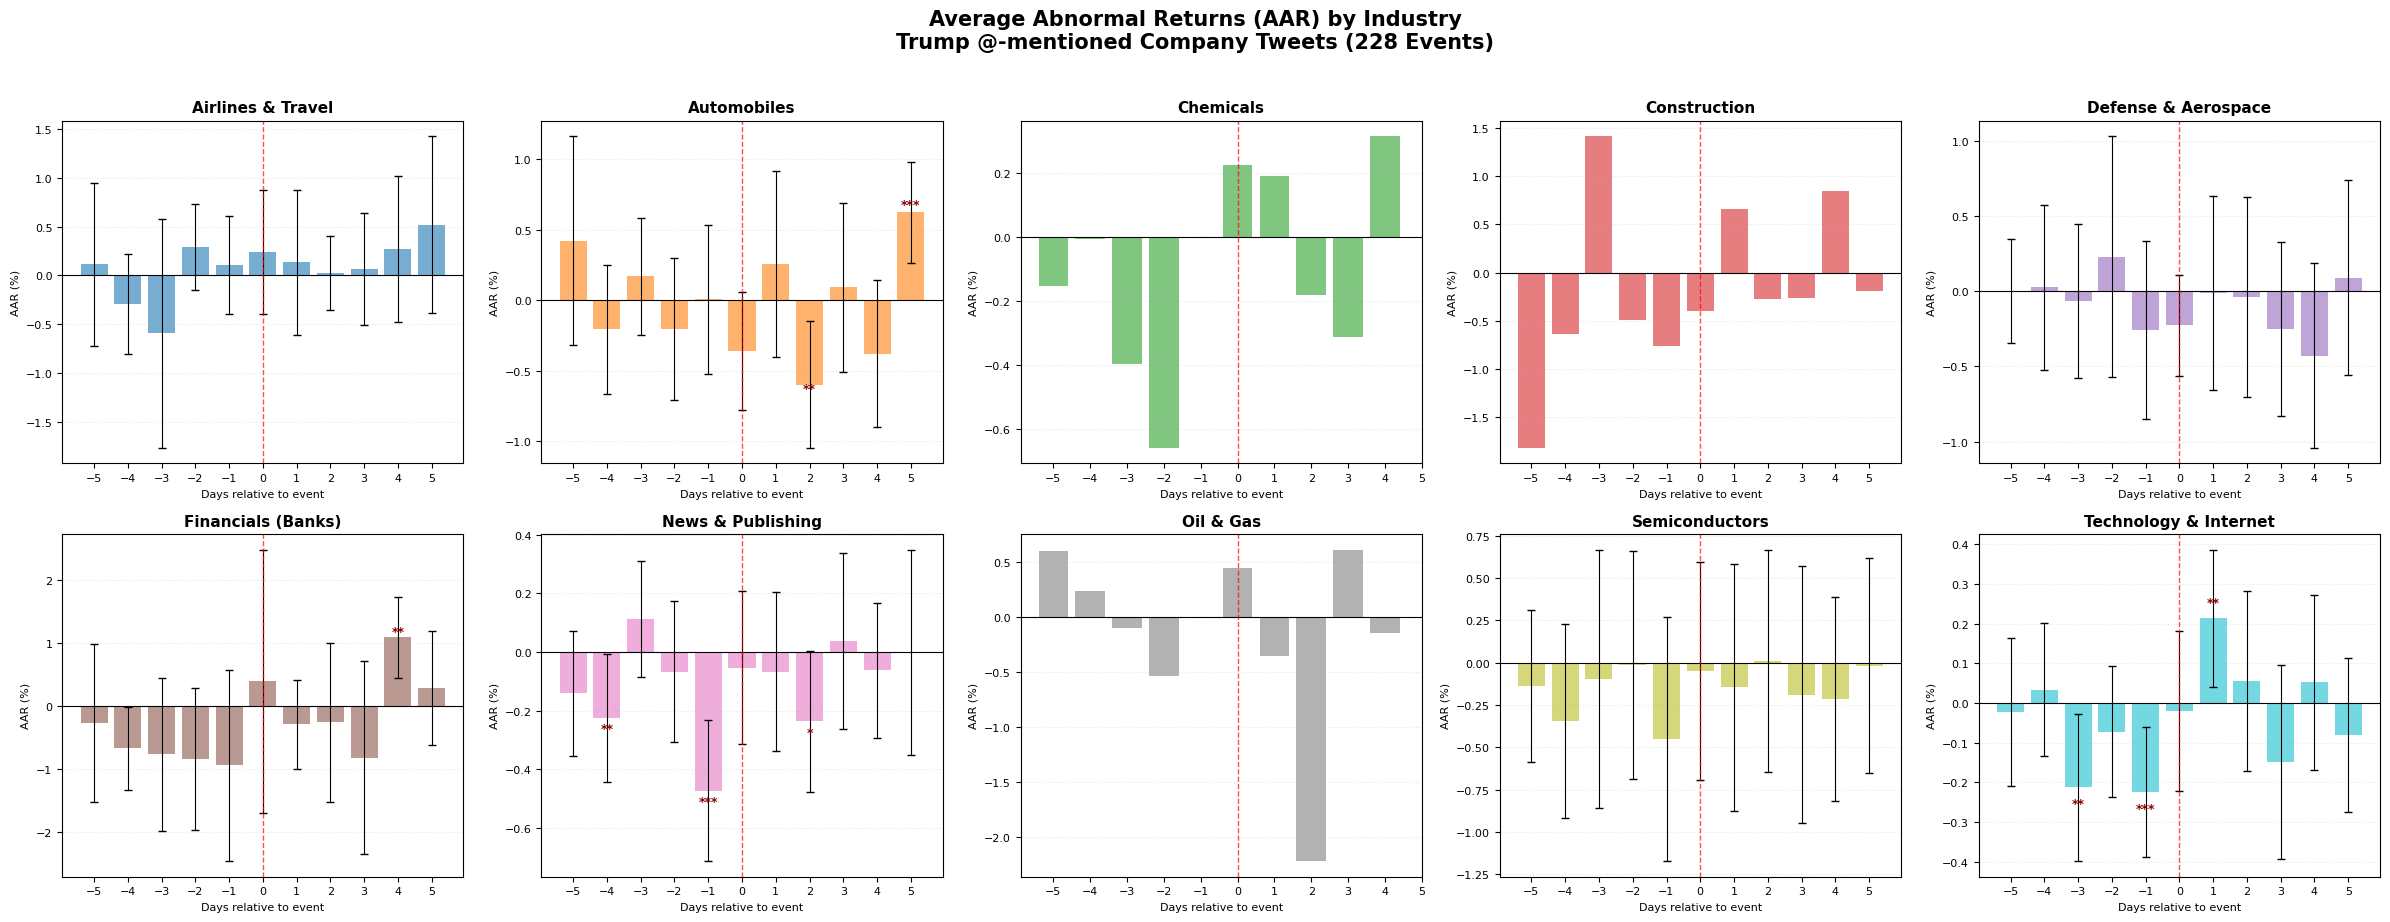

✅ Saved: AAR_all_industries.png


In [30]:
fig, axes = plt.subplots(2, 5, figsize=(24, 9))
axes = axes.flatten()

for idx, prefix in enumerate(INDUSTRIES):
    ax    = axes[idx]
    df_r  = results[prefix]
    t_v   = df_r.index.tolist()
    aar   = df_r['AAR'].values * 100
    se    = df_r['SE'].values * 100
    color = COLOR_MAP[prefix]

    ax.bar(t_v, aar, color=color, alpha=0.6)
    ax.errorbar(t_v, aar, yerr=1.96*se, fmt='none', color='black', capsize=3, linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='red',   linewidth=1, linestyle='--', alpha=0.7)

    for t in t_v:
        p = df_r.loc[t,'p_value'] if t in df_r.index else np.nan
        a = df_r.loc[t,'AAR']*100 if t in df_r.index else np.nan
        stars = sig_stars(p)
        if stars:
            ax.text(t, a + (0.03 if a >= 0 else -0.05), stars,
                    ha='center', fontsize=9, color='darkred', fontweight='bold')

    ax.set_title(INDUSTRY_LABELS[prefix], fontsize=11, fontweight='bold')
    ax.set_xlabel('Days relative to event', fontsize=8)
    ax.set_ylabel('AAR (%)', fontsize=8)
    ax.set_xticks(event_days); ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle=':')

fig.suptitle('Average Abnormal Returns (AAR) by Industry\n'
             'Trump @-mentioned Company Tweets (228 Events)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('AAR_all_industries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: AAR_all_industries.png")

### 6d: Combined CAAR Overlay

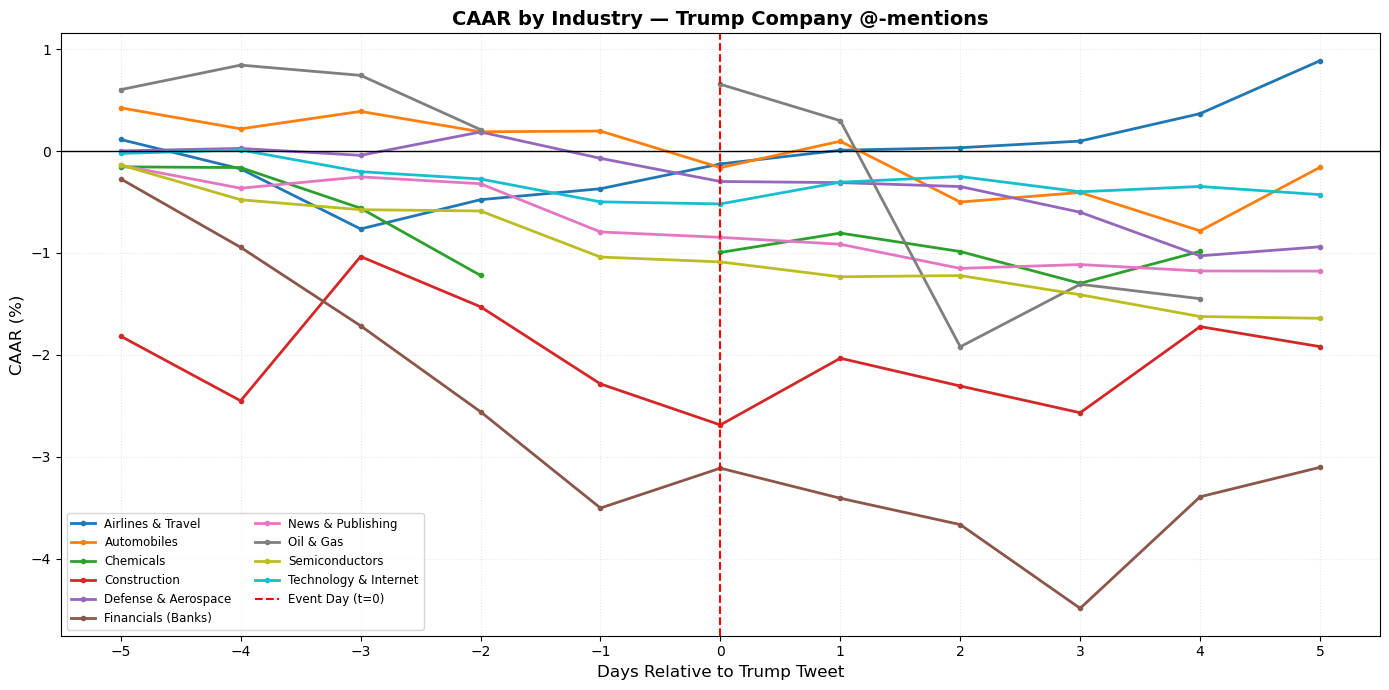

✅ Saved: CAAR_combined_overlay.png


In [39]:
fig, ax = plt.subplots(figsize=(14, 7))

for idx, prefix in enumerate(INDUSTRIES):
    df_r  = results[prefix]
    caar  = df_r['CAAR'].values * 100
    ax.plot(df_r.index.tolist(), caar,
            color=COLOR_MAP[prefix], linewidth=2, marker='o', markersize=3,
            label=INDUSTRY_LABELS[prefix])

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='red',   linewidth=1.5, linestyle='--', label='Event Day (t=0)')
ax.set_xlabel('Days Relative to Trump Tweet', fontsize=12)
ax.set_ylabel('CAAR (%)', fontsize=12)
ax.set_title('CAAR by Industry — Trump Company @-mentions',
             fontsize=14, fontweight='bold')
ax.set_xticks(event_days)
ax.grid(alpha=0.3, linestyle=':')
ax.legend(loc='lower left', fontsize=8.5, ncol=2)

plt.tight_layout()
plt.savefig('CAAR_combined_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: CAAR_combined_overlay.png")

---
## Step 7: Patell Standardized Test (Robustness Check)

$$SAR_{i,t} = \frac{AR_{i,t}}{S_{AR,i}}, \quad Z_{Patell,t} = \frac{1}{\sqrt{N}}\sum SAR_{i,t}$$

In [32]:
# Compute residual std from estimation window for each tweet-industry
resid_store = {}  # (prefix, tid) → s_ar

for prefix in INDUSTRIES:
    ret_col = INDUSTRY_COLS[prefix]
    for tid, df in panels[prefix]:
        if ret_col in df.columns:
            rc = ret_col
        else:
            rcs = [c for c in df.columns if 'return' in c.lower()]
            rc  = rcs[0] if rcs else None
        if rc is None: continue
        
        est = df[(df.index >= EST_START) & (df.index <= EST_END)][['Market_Return', rc]].dropna()
        if len(est) < 30: continue
        X = sm.add_constant(est['Market_Return'].values)
        try:
            m = sm.OLS(est[rc].values, X).fit()
            resid_store[(prefix, tid)] = np.std(m.resid, ddof=2)
        except: pass

# Compute SAR matrix and Patell Z
sar_matrix = {p: {t: [] for t in event_days} for p in INDUSTRIES}

for prefix in INDUSTRIES:
    ret_col = INDUSTRY_COLS[prefix]
    for tid, df in panels[prefix]:
        if ret_col in df.columns:
            rc = ret_col
        else:
            rcs = [c for c in df.columns if 'return' in c.lower()]
            rc  = rcs[0] if rcs else None
        if rc is None: continue
        
        key = (prefix, tid)
        alpha, beta, _, _ = param_store[prefix].get(tid, (np.nan,np.nan,np.nan,0))
        s_ar = resid_store.get(key, np.nan)
        if np.isnan(alpha) or np.isnan(s_ar) or s_ar == 0: continue
        
        evt = df[(df.index >= EVT_START) & (df.index <= EVT_END)]
        for t in event_days:
            if t not in evt.index: continue
            row = evt.loc[t]
            r_a, r_m = row[rc], row['Market_Return']
            if pd.isna(r_a) or pd.isna(r_m): continue
            ar = r_a - (alpha + beta * r_m)
            sar_matrix[prefix][t].append(ar / s_ar)

print("Patell Z-test at t=0:")
print("-" * 50)
for prefix in INDUSTRIES:
    sars = sar_matrix[prefix][0]; n = len(sars)
    if n == 0: continue
    Z = np.sum(sars) / np.sqrt(n)
    p = 2 * stats.norm.sf(abs(Z))
    print(f"  {INDUSTRY_LABELS[prefix]:<35}  Z={Z:+.3f}  p={p:.4f} {sig_stars(p)}")
print("\n* p<0.10  ** p<0.05  *** p<0.01")

Patell Z-test at t=0:
--------------------------------------------------
  Airlines & Travel                    Z=+0.572  p=0.5676 
  Automobiles                          Z=-1.164  p=0.2444 
  Chemicals                            Z=+0.380  p=0.7043 
  Construction                         Z=-0.343  p=0.7315 
  Defense & Aerospace                  Z=-0.777  p=0.4369 
  Financials (Banks)                   Z=+0.544  p=0.5867 
  News & Publishing                    Z=-0.345  p=0.7299 
  Oil & Gas                            Z=+0.491  p=0.6234 
  Semiconductors                       Z=-0.204  p=0.8385 
  Technology & Internet                Z=-0.271  p=0.7864 

* p<0.10  ** p<0.05  *** p<0.01


---
## Step 8: PPT-Ready Individual Industry Plots

In [33]:
os.makedirs('ppt_plots', exist_ok=True)

for idx, prefix in enumerate(INDUSTRIES):
    df_r  = results[prefix]
    t_v   = df_r.index.tolist()
    aar   = df_r['AAR'].values * 100
    se    = df_r['SE'].values * 100
    caar  = df_r['CAAR'].values * 100
    cse   = df_r['CAAR_SE'].values * 100
    color = COLOR_MAP[prefix]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: AAR
    bar_c = [color if a >= 0 else 'firebrick' for a in aar]
    ax1.bar(t_v, aar, color=bar_c, alpha=0.7, edgecolor='white')
    ax1.errorbar(t_v, aar, yerr=1.96*se, fmt='none', color='black', capsize=4)
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axvline(0, color='red',   linewidth=1.5, linestyle='--', alpha=0.8)
    for t in t_v:
        p = df_r.loc[t,'p_value'] if t in df_r.index else np.nan
        a = df_r.loc[t,'AAR']*100 if t in df_r.index else np.nan
        if sig_stars(p):
            ax1.text(t, a+(0.03 if a>=0 else -0.05), sig_stars(p),
                     ha='center', fontsize=9, color='darkred', fontweight='bold')
    ax1.set_xlabel('Days Relative to Tweet'); ax1.set_ylabel('AAR (%)')
    ax1.set_title('Average Abnormal Return (AAR)')
    ax1.set_xticks(event_days); ax1.grid(axis='y', alpha=0.3, linestyle=':')

    # Right: CAAR
    ax2.plot(t_v, caar, color=color, linewidth=2.5, marker='o', markersize=5)
    ax2.fill_between(t_v, caar-1.96*cse, caar+1.96*cse,
                     color=color, alpha=0.15, label='95% CI')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.axvline(0, color='red',   linewidth=1.5, linestyle='--', alpha=0.8)
    c5 = df_r.loc[EVT_END,'CAAR']*100 if EVT_END in df_r.index else np.nan
    p5 = df_r.loc[EVT_END,'CAAR_p']   if EVT_END in df_r.index else np.nan
    if not np.isnan(c5):
        ax2.annotate(f'CAAR={c5:.3f}%{sig_stars(p5)}',
                     xy=(EVT_END, c5), xytext=(3,0),
                     textcoords='offset points', fontsize=9,
                     color='darkred' if sig_stars(p5) else 'gray')
    ax2.set_xlabel('Days Relative to Tweet'); ax2.set_ylabel('CAAR (%)')
    ax2.set_title('Cumulative Average Abnormal Return (CAAR)')
    ax2.set_xticks(event_days); ax2.grid(alpha=0.3, linestyle=':')
    ax2.legend(fontsize=9)

    n_ev = int(df_r.loc[0,'N']) if 0 in df_r.index else '?'
    fig.suptitle(f"{INDUSTRY_LABELS[prefix]}\n"
                 f"N={n_ev} events | CAPM | Estimation Window [-250,-10]",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    safe = INDUSTRY_LABELS[prefix].replace(' ','_').replace('&','and').replace('/','_')
    plt.savefig(f'ppt_plots/{safe}.png', dpi=200, bbox_inches='tight')
    plt.close()

print("✅ All 10 individual plots saved to ./ppt_plots/")

✅ All 10 individual plots saved to ./ppt_plots/


---
## Step 9: Export Results

In [34]:
all_rows = []
for prefix in INDUSTRIES:
    df_r = results[prefix].reset_index()
    df_r['industry'] = INDUSTRY_LABELS[prefix]
    for col in ['AAR','CAAR','SE','CAAR_SE']:
        if col in df_r.columns:
            df_r[col] = df_r[col] * 100
    all_rows.append(df_r)

pd.concat(all_rows).to_csv('event_study_AAR_CAAR_results.csv', index=False)
sig_table.to_csv('event_study_significance_summary.csv', index=False)
print("✅ Results exported:")
print("   event_study_AAR_CAAR_results.csv")
print("   event_study_significance_summary.csv")

✅ Results exported:
   event_study_AAR_CAAR_results.csv
   event_study_significance_summary.csv
